In [8]:
!pip install astroplan astroquery

In [ ]:
import matplotlib.pyplot as plt
from astroplan import FixedTarget
from astroplan.plots import plot_finder_image

messier1 = FixedTarget.from_name("M1")

plot_finder_image(messier1)
# ax, hdu = plot_finder_image(messier1)

# plt.show()

TypeError: SkyViewClass.get_images() got an unexpected keyword argument 'grid'

In [153]:
from astroquery.simbad import Simbad

simbad = Simbad()
simbad.ROW_LIMIT = 5000
m81_table = simbad.query_object("m81")
m81_region_table = simbad.query_region("m81", radius="0.1d")
m81_region_table

main_id,ra,dec,coo_err_maj,coo_err_min,coo_err_angle,coo_wavelength,coo_bibcode
,deg,deg,mas,mas,deg,,
object,float64,float64,float32,float32,int16,str1,object
PNV J09555331+6858162,148.97212499999998,68.97116666666668,--,--,--,,2017ATel10134....1H
[HAE2008] 2,148.92107083333332,68.99606111111112,--,--,--,,2008ApJ...673..798H
[HAE2008] 10,148.86777499999997,68.97990555555556,--,--,--,,2008ApJ...673..798H
[GKP2011] M81C J095550.57+685918.8,148.96070833333334,68.98855555555555,--,--,--,O,2011ApJ...743..176G
[PR95] 50179,148.94533333333334,68.9889388888889,--,--,--,O,2010AJ....139.2620N
[NHZ2011] 259,148.93454166666666,68.99805555555555,--,--,--,O,2011AJ....142..183N
[GMR2016] WR17,148.94600833333334,68.98860277777777,--,--,--,O,2020MNRAS.493.3879G
[MPC2001] 117,148.95879166666668,68.99677777777778,--,--,--,O,2001A&A...379...90M


In [154]:
import xarray as xr
import astropy_xarray

m81_region = xr.Dataset(
    data_vars={
        name: xr.DataArray(
            col,
            dims=['main_id'],
            attrs={
                'description': col.description,
                'units': col.unit
            }
        ) for name, col in m81_region_table.items()
    }
).astropy.quantify()
m81_region


<xarray.Dataset> Size: 94kB
Dimensions:         (main_id: 1960)
Coordinates:
  * main_id         (main_id) object 16kB 'PNV J09555331+6858162' ... 'SDSSCG...
Data variables:
    ra              (main_id) float64 16kB [deg] 149.0 148.9 ... 148.7 148.8
    dec             (main_id) float64 16kB [deg] 68.97 69.0 68.98 ... 69.01 69.0
    coo_err_maj     (main_id) float32 8kB [mas] nan nan nan nan ... nan nan nan
    coo_err_min     (main_id) float32 8kB [mas] nan nan nan nan ... nan nan nan
    coo_err_angle   (main_id) float32 8kB [deg] nan nan nan nan ... nan nan nan
    coo_wavelength  (main_id) <U1 8kB '' '' '' 'O' 'O' ... 'X' 'O' 'X' '' 'O'
    coo_bibcode     (main_id) object 16kB '2017ATel10134....1H' ... '2009MNRA...

main_id,ra,dec,coo_err_maj,coo_err_min,coo_err_angle,coo_wavelength,coo_bibcode,matched_id
,deg,deg,mas,mas,deg,,,
object,float64,float64,float32,float32,int16,str1,object,object
M 81,148.88821939854,69.06529514038,0.0459,0.0494,90,O,2020yCat.1350....0G,M 81


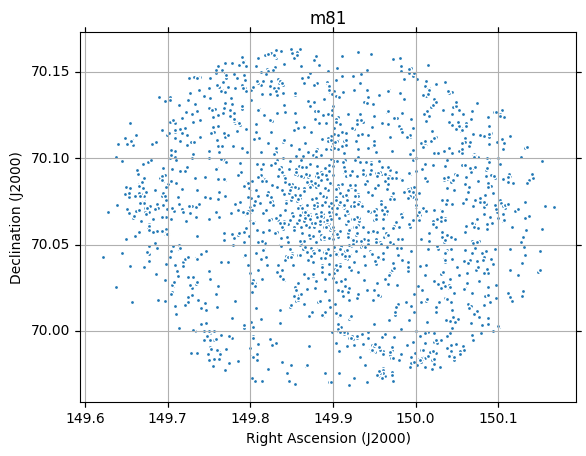

In [163]:
import matplotlib.pyplot as plt
from astropy.wcs import WCS


wcs = WCS()
fig, ax = plt.subplots(subplot_kw={'projection': wcs, 'label': 'overlays'})
ax.grid(True)
# ax.set_rmin(60)
# ax.set_rmax(100)
# set_rorigin(70)
# ax.set_thetamin(135)
# ax.set_thetamax(180)


m81_region.plot.scatter(x='ra', y='dec', ax=ax, marker='.')
ax.set_title("m81")
ax.set(xlabel='Right Ascension (J2000)', ylabel='Declination (J2000)')



# m81_table.to_pandas().plot.scatter(x='ra', y='dec', ax=ax, marker='X')
m81_table